## 1.setup

In [2]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
np.random.seed(42)
pd.set_option("display.max_columns",50)
sns.set_style("whitegrid")

## 2. Load dataset

In [5]:
titanic=sns.load_dataset("titanic")

In [6]:
df=pd.DataFrame(titanic)

In [7]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [8]:
df.shape

(891, 15)

In [9]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')

In [10]:
nums_cols=["age","fare","sibsp","parch"]
cat_cols=["survived","pclass","sex","embarked","class","who","adult_male","deck","embark_town","alone"]
print(nums_cols,"\n")
print(cat_cols,"\n")

['age', 'fare', 'sibsp', 'parch'] 

['survived', 'pclass', 'sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alone'] 



## 3. Numerical data Analysis

In [11]:
df[nums_cols].head() 

,age,fare,sibsp,parch
0,22.0,7.2500,1,0
1,38.0,71.2833,1,0
2,26.0,7.9250,0,0
3,35.0,53.1000,1,0
4,35.0,8.0500,0,0


3.1 Summary statistics


In [12]:
df[nums_cols
   ].describe()

,age,fare,sibsp,parch
count,714.000000,891.000000,891.000000,891.000000
mean,29.699118,32.204208,0.523008,0.381594
std,14.526497,49.693429,1.102743,0.806057
min,0.420000,0.000000,0.000000,0.000000
25%,20.125000,7.910400,0.000000,0.000000
50%,28.000000,14.454200,0.000000,0.000000
75%,38.000000,31.000000,1.000000,0.000000
max,80.000000,512.329200,8.000000,6.000000


In [13]:
print(df[nums_cols].mode())
print(df[nums_cols].median())

print(df[nums_cols].mean())


    age  fare  sibsp  parch
0  24.0  8.05      0      0
age      28.0000
fare     14.4542
sibsp     0.0000
parch     0.0000
dtype: float64
age      29.699118
fare     32.204208
sibsp     0.523008
parch     0.381594
dtype: float64


3.3 Variance and standard deviation


In [14]:
print("Variance:")
print(df[nums_cols].var())

Variance:
age       211.019125
fare     2469.436846
sibsp       1.216043
parch       0.649728
dtype: float64


In [15]:
print("standard Devaiation:")
print(df[nums_cols].std())

standard Devaiation:
age      14.526497
fare     49.693429
sibsp     1.102743
parch     0.806057
dtype: float64


3.4 Skewness and Kurtosis


In [16]:
print("skewness:")
print(df[nums_cols].skew())

print("\n kuartosis:")
print(df[nums_cols].kurtosis())

skewness:
age      0.389108
fare     4.787317
sibsp    3.695352
parch    2.749117
dtype: float64

 kuartosis:
age       0.178274
fare     33.398141
sibsp    17.880420
parch     9.778125
dtype: float64


3.5 Histogram

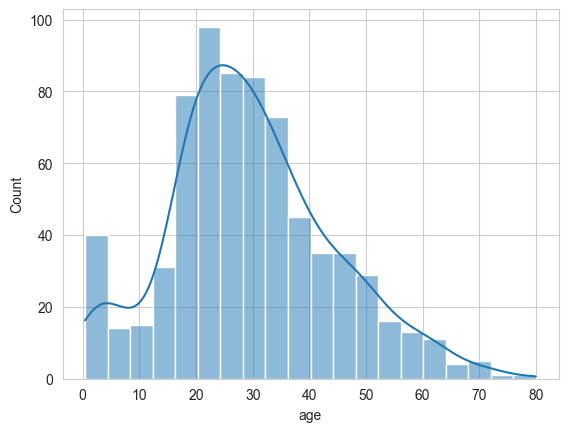

In [17]:
sns.histplot(df['age'],kde=True)
plt.show()

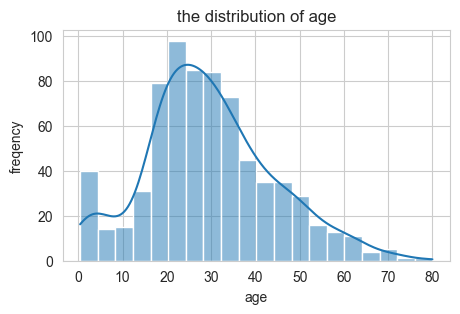

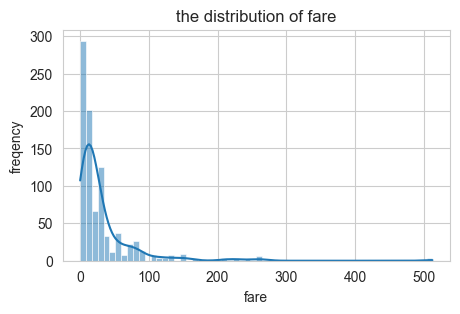

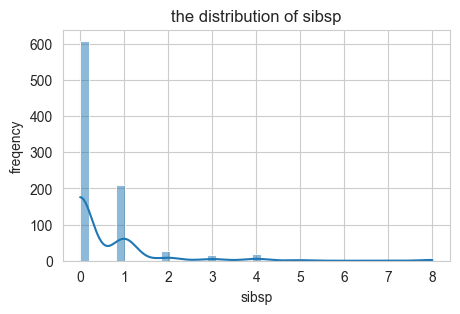

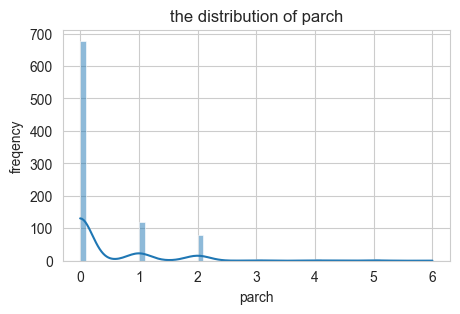

In [18]:
for col in nums_cols:
    plt.figure(figsize=(5,3))
    sns.histplot(df[col],kde=True)
    plt.title(f"the distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("freqency")
    plt.show()

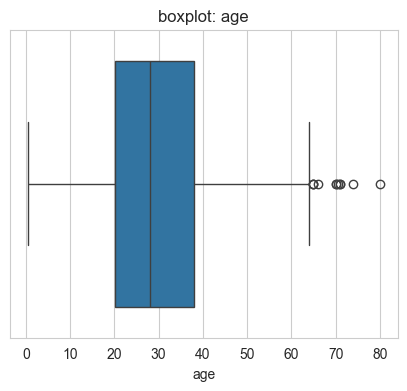

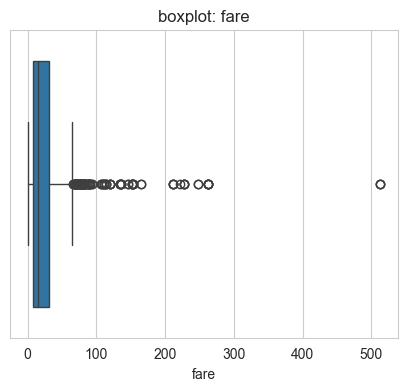

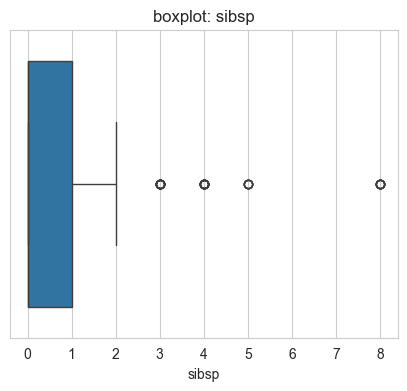

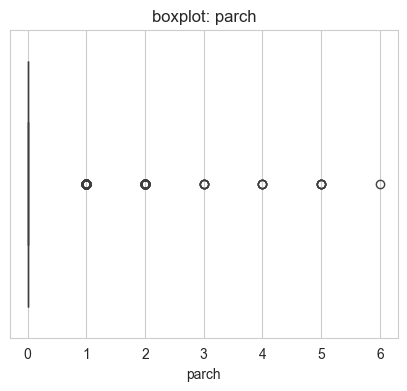

In [19]:
 for col in nums_cols:
     plt.figure(figsize=(5,4))
     sns.boxplot(x=df[col])
     plt.title(f"boxplot: {col}")
     plt.show()

In [20]:
df[nums_cols].describe()

,age,fare,sibsp,parch
count,714.000000,891.000000,891.000000,891.000000
mean,29.699118,32.204208,0.523008,0.381594
std,14.526497,49.693429,1.102743,0.806057
min,0.420000,0.000000,0.000000,0.000000
25%,20.125000,7.910400,0.000000,0.000000
50%,28.000000,14.454200,0.000000,0.000000
75%,38.000000,31.000000,1.000000,0.000000
max,80.000000,512.329200,8.000000,6.000000


## 4 categorical Features

In [21]:
cat_cols

['survived',
 'pclass',
 'sex',
 'embarked',
 'class',
 'who',
 'adult_male',
 'deck',
 'embark_town',
 'alone']

In [22]:
df[cat_cols].head()

,survived,pclass,sex,embarked,class,who,adult_male,deck,embark_town,alone
0,0,3,male,S,Third,man,True,NaN,Southampton,False
1,1,1,female,C,First,woman,False,C,Cherbourg,False
2,1,3,female,S,Third,woman,False,NaN,Southampton,True
3,1,1,female,S,First,woman,False,C,Southampton,False
4,0,3,male,S,Third,man,True,NaN,Southampton,True


5.1 Frequency Table


In [23]:
print(df["pclass"].value_counts())
print("-"*50)

print(df["pclass"].value_counts(normalize=True))

pclass
3    491
1    216
2    184
Name: count, dtype: int64
--------------------------------------------------
pclass
3    0.551066
1    0.242424
2    0.206510
Name: proportion, dtype: float64


In [24]:
for col in cat_cols:
    print(df[col].value_counts())

    print(df[col].value_counts(normalize=True))
    print("-"*50)
    
    

survived
0    549
1    342
Name: count, dtype: int64
survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64
--------------------------------------------------
pclass
3    491
1    216
2    184
Name: count, dtype: int64
pclass
3    0.551066
1    0.242424
2    0.206510
Name: proportion, dtype: float64
--------------------------------------------------
sex
male      577
female    314
Name: count, dtype: int64
sex
male      0.647587
female    0.352413
Name: proportion, dtype: float64
--------------------------------------------------
embarked
S    644
C    168
Q     77
Name: count, dtype: int64
embarked
S    0.724409
C    0.188976
Q    0.086614
Name: proportion, dtype: float64
--------------------------------------------------
class
Third     491
First     216
Second    184
Name: count, dtype: int64
class
Third     0.551066
First     0.242424
Second    0.206510
Name: proportion, dtype: float64
--------------------------------------------------
who
man      537
woman    271
c

5.2 Count Plot


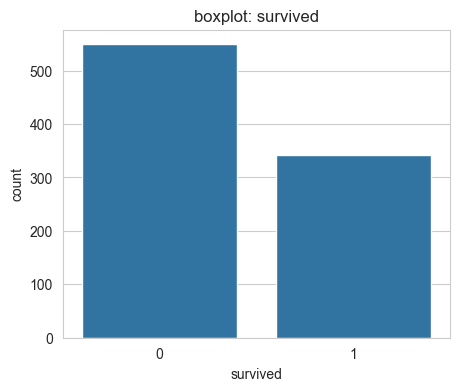

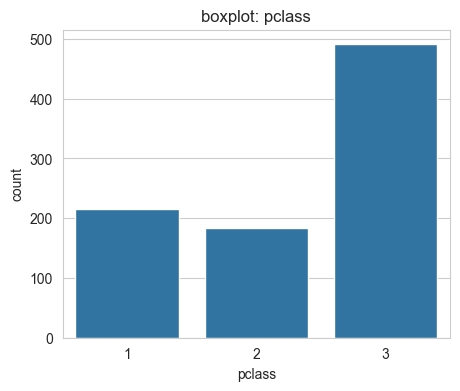

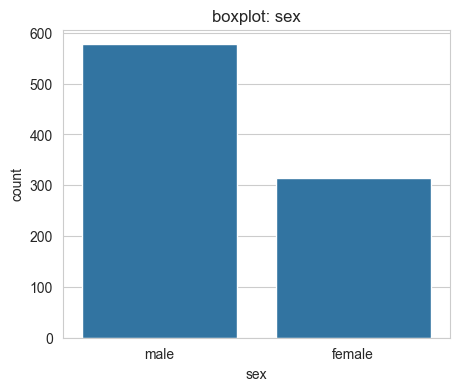

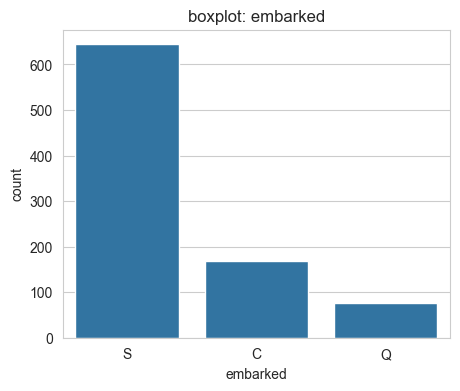

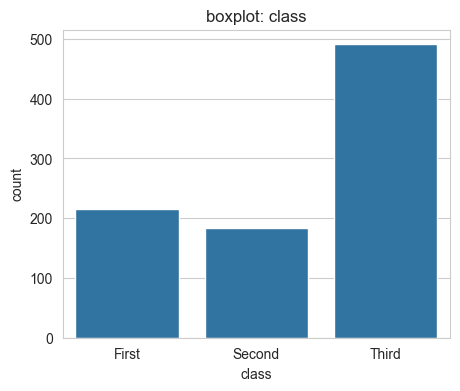

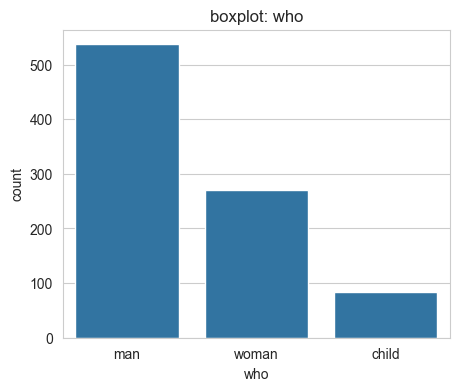

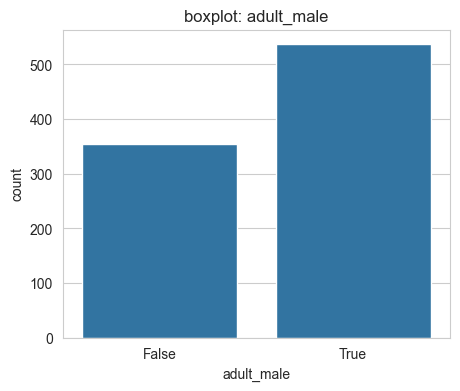

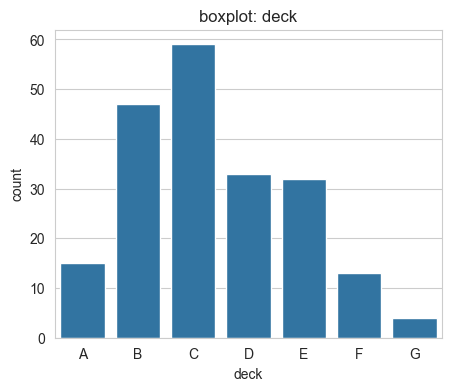

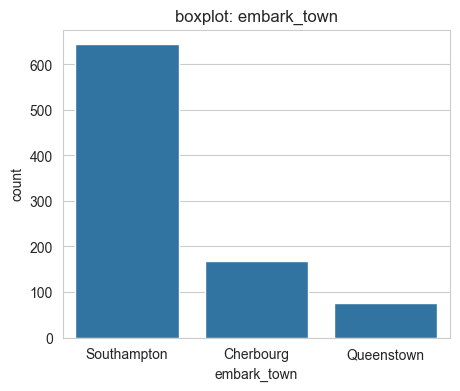

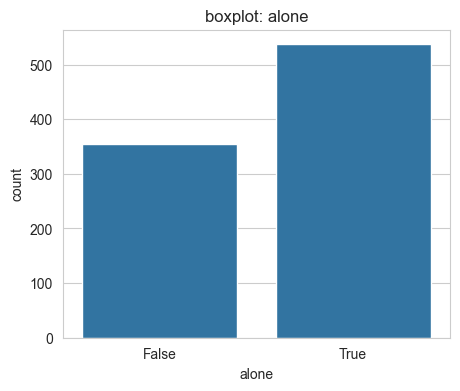

In [25]:
 for col in cat_cols:
     plt.figure(figsize=(5,4))
     sns.countplot(x=df[col])
     plt.title(f"boxplot: {col}")
     plt.show()

3 Numerical vs Numerical

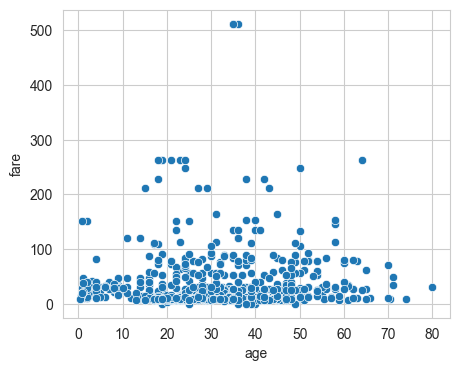

In [28]:
plt.figure(figsize=(5,4))
sns.scatterplot(x=df["age"],y=df["fare"])
plt.show()

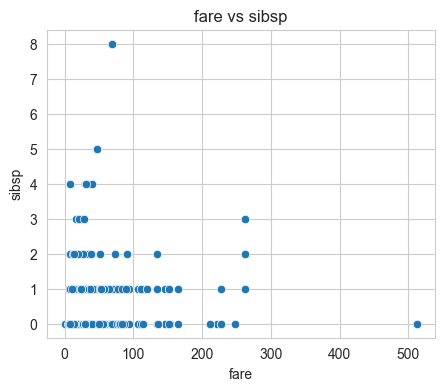

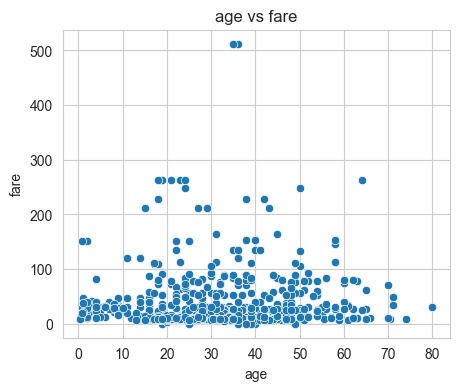

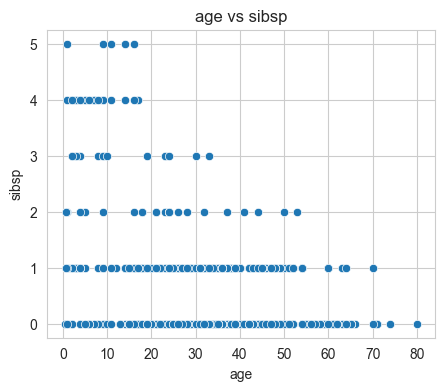

In [31]:
num_pairs={
    ("age","fare"),
    ("age","sibsp"),
    ("fare","sibsp")
}
for x,y in num_pairs:
    plt.figure(figsize=(5,4))
    sns.scatterplot(x=df[x],y=df[y])
    plt.title(f"{x} vs {y}")
    plt.xlabel(x)
    plt.ylabel(y)
    plt.show()

3.2 Correlation matrix